In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import metrics

names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class']

# names=names: 파일에 칼럼(열) 이름이 없기 때문에 사용
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Algorithm/iris.data', names=names)

In [4]:
X = dataset.iloc[:, :-1].values # 모든 행을 가져오되, 마지막 열만 제외하고 선택(특성 데이터)
y = dataset.iloc[:, 4].values # 모든 행의 5번째(인덱스 4) 열만 선택(정답 데이터: 꽃의 종류)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

from sklearn.preprocessing import StandardScaler
s = StandardScaler() # 특성 스케일(scaling), 평균이 0, 표준편차가 1이 되도록 변환
X_train = s.fit_transform(X_train) # 기준을 찾고(fit) 바로 변환(transform) 한다.
X_test = s.transform(X_test) # 이미 찾은 기준을 그래도 적용(transform)만 한다.

In [5]:
from sklearn.neighbors import KNeighborsClassifier

# n_neighbors=50: 새로운 데이터를 예측할 때, 가장 가까운 이웃 50를 보고 다수결로 결정하겠다는 뜻
knn = KNeighborsClassifier(n_neighbors=50) # K가 50인 KNN 모델 객체 생성
knn.fit(X_train, y_train) # 모델 학습

KNeighborsClassifier(n_neighbors=50)

In [6]:
from sklearn.metrics import accuracy_score
y_pred = knn.predict(X_test)
print("정확도: {}".format(accuracy_score(y_test, y_pred)))

정확도: 0.8666666666666667


In [8]:
k = 10
acc_array = np.zeros(k)
for k in np.arange(1, k+1, 1):
  classifier = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
  y_pred = classifier.predict(X_test)
  acc = metrics.accuracy_score(y_test, y_pred)
  acc_array[k-1] = acc

max_acc = np.amax(acc_array)
acc_list = list(acc_array)
k = acc_list.index(max_acc)
print("정확도", max_acc, "으로 최적의 k는", k+1, "입니다.")

정확도 1.0 으로 최적의 k는 2 입니다.


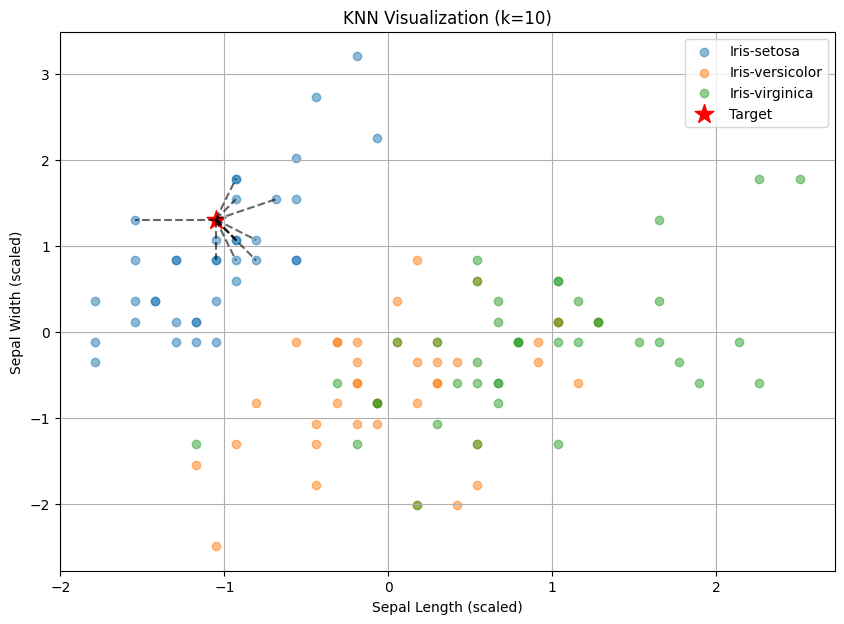

타겟의 실제 클래스: Iris-setosa
KNN의 예측 클래스: Iris-setosa


In [10]:
# 시각화할 샘플 선택 (X_test 중에서 하나 선택)
sample_index = 0  # 0번 데이터를 샘플로 지정

# reshape(1, -1): 기존 X_test[0]는 1차원 형태으로 행렬로 만들어야 함
target_sample = X_test[sample_index].reshape(1, -1)
target_label = y_test[sample_index]

# 2. 최적의 k값 또는 확인하고 싶은 k값 설정
k_val = 10
visual_knn = KNeighborsClassifier(n_neighbors=k_val)
visual_knn.fit(X_train, y_train)

# 3. 타겟 데이터와 가장 가까운 이웃들의 거리(dist)와 인덱스(ind) 찾기
dist, ind = visual_knn.kneighbors(target_sample)

# 4. 그래프 그리기
plt.figure(figsize=(10, 7))

# 중복되지 않은 이름들만 뽑아낸다.
labels = np.unique(y_train)
for l in labels:

    # alpha=0.5: 점을 50% 정도 투명하게 만듦
    plt.scatter(X_train[y_train == l, 0], X_train[y_train == l, 1], label=l, alpha=0.5)

# 예측할 타겟 샘플 (빨간 별 모양)
plt.scatter(target_sample[0, 0], target_sample[0, 1], c='red', marker='*', s=200, label='Target')

# 핵심: 타겟과 가장 가까운 이웃들을 선으로 연결 (이것이 '거리'입니다)
for i in ind[0]:
    plt.plot([target_sample[0, 0], X_train[i, 0]],
             [target_sample[0, 1], X_train[i, 1]],
             'k--', alpha=0.6) # 검은색 점선 연결

plt.xlabel('Sepal Length (scaled)')
plt.ylabel('Sepal Width (scaled)')
plt.title(f'KNN Visualization (k={k_val})')
plt.legend()
plt.grid(True)
plt.show()

print(f"타겟의 실제 클래스: {target_label}")
print(f"KNN의 예측 클래스: {visual_knn.predict(target_sample)[0]}")